In [31]:
print("Glassdoor Salary Prediction Project")
print("Python is working successfully")

Glassdoor Salary Prediction Project
Python is working successfully


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("glassdoor_jobs.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (956, 15)


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [33]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112

In [34]:
print("Column Names:")
print(df.columns.tolist())

print("\nSample Job Titles:")
print(df["Job Title"].head(10))

print("\nSample Salary Estimates:")
print(df["Salary Estimate"].head(10))

Column Names:
['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']

Sample Job Titles:
0               Data Scientist
1    Healthcare Data Scientist
2               Data Scientist
3               Data Scientist
4               Data Scientist
5               Data Scientist
6               Data Scientist
7               Data Scientist
8           Research Scientist
9               Data Scientist
Name: Job Title, dtype: object

Sample Salary Estimates:
0      $53K-$91K (Glassdoor est.)
1     $63K-$112K (Glassdoor est.)
2      $80K-$90K (Glassdoor est.)
3      $56K-$97K (Glassdoor est.)
4     $86K-$143K (Glassdoor est.)
5     $71K-$119K (Glassdoor est.)
6      $54K-$93K (Glassdoor est.)
7     $86K-$142K (Glassdoor est.)
8      $38K-$84K (Glassdoor est.)
9    $120K-$160K (Glassdoor est.)
Name: Salary Estimate, dtype: object


In [35]:
import re

def extract_salary(salary):
    if pd.isna(salary):
        return pd.Series([np.nan, np.nan])

    values = re.findall(r'\$(\d+(?:\.\d+)?)\s*([Kk]?)', str(salary))

    if len(values) < 2:
        return pd.Series([np.nan, np.nan])

    salaries = [
        float(value) * (1000 if unit.lower() == "k" else 1)
        for value, unit in values[:2]
    ]

    if "per hour" in str(salary).lower():
        salaries = [s * 2080 for s in salaries]

    return pd.Series(salaries)

df[["Min_Salary", "Max_Salary"]] = df["Salary Estimate"].apply(extract_salary)

df[["Salary Estimate", "Min_Salary", "Max_Salary"]].head(10)

,Salary Estimate,Min_Salary,Max_Salary
0,$53K-$91K (Glassdoor est.),53000.0,91000.0
1,$63K-$112K (Glassdoor est.),63000.0,112000.0
2,$80K-$90K (Glassdoor est.),80000.0,90000.0
3,$56K-$97K (Glassdoor est.),56000.0,97000.0
4,$86K-$143K (Glassdoor est.),86000.0,143000.0
5,$71K-$119K (Glassdoor est.),71000.0,119000.0
6,$54K-$93K (Glassdoor est.),54000.0,93000.0
7,$86K-$142K (Glassdoor est.),86000.0,142000.0
8,$38K-$84K (Glassdoor est.),38000.0,84000.0
9,$120K-$160K (Glassdoor est.),120000.0,160000.0


In [36]:
df["Average_Salary"] = (df["Min_Salary"] + df["Max_Salary"]) / 2

print("Salary statistics:")
print(df[["Min_Salary", "Max_Salary", "Average_Salary"]].describe())

print("\nAverage Salary of first 10 jobs:")
df[["Job Title", "Min_Salary", "Max_Salary", "Average_Salary"]].head(10)

Salary statistics:
          Min_Salary     Max_Salary  Average_Salary
count     742.000000     742.000000      742.000000
mean    74771.752022  128226.900270   101499.326146
std     30926.957646   45110.814223    37463.032093
min     15000.000000   16000.000000    15500.000000
25%     52000.000000   96000.000000    73500.000000
50%     69500.000000  124000.000000    97500.000000
75%     91000.000000  155000.000000   122500.000000
max    202000.000000  306000.000000   254000.000000

Average Salary of first 10 jobs:


,Job Title,Min_Salary,Max_Salary,Average_Salary
0,Data Scientist,53000.0,91000.0,72000.0
1,Healthcare Data Scientist,63000.0,112000.0,87500.0
2,Data Scientist,80000.0,90000.0,85000.0
3,Data Scientist,56000.0,97000.0,76500.0
4,Data Scientist,86000.0,143000.0,114500.0
5,Data Scientist,71000.0,119000.0,95000.0
6,Data Scientist,54000.0,93000.0,73500.0
7,Data Scientist,86000.0,142000.0,114000.0
8,Research Scientist,38000.0,84000.0,61000.0
9,Data Scientist,120000.0,160000.0,140000.0


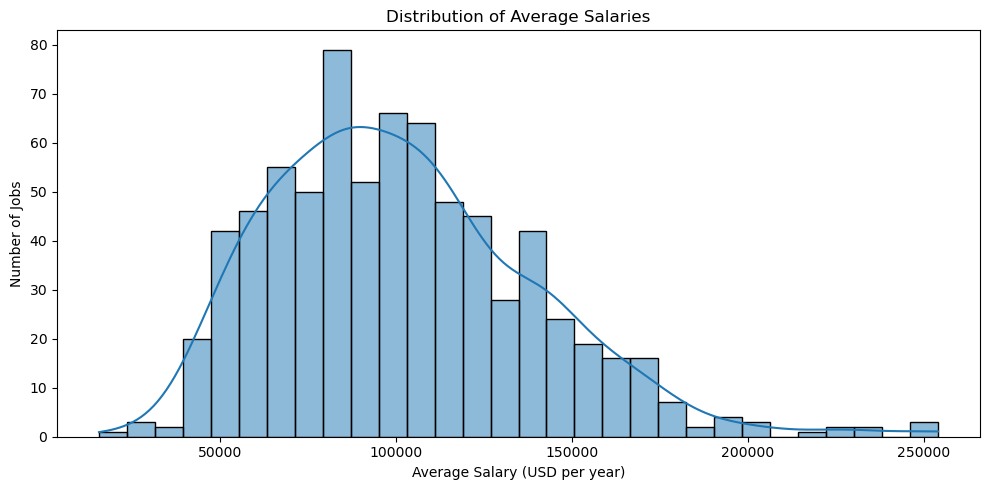

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Average_Salary",
    bins=30,
    kde=True
)

plt.title("Distribution of Average Salaries")
plt.xlabel("Average Salary (USD per year)")
plt.ylabel("Number of Jobs")

plt.tight_layout()
plt.show()

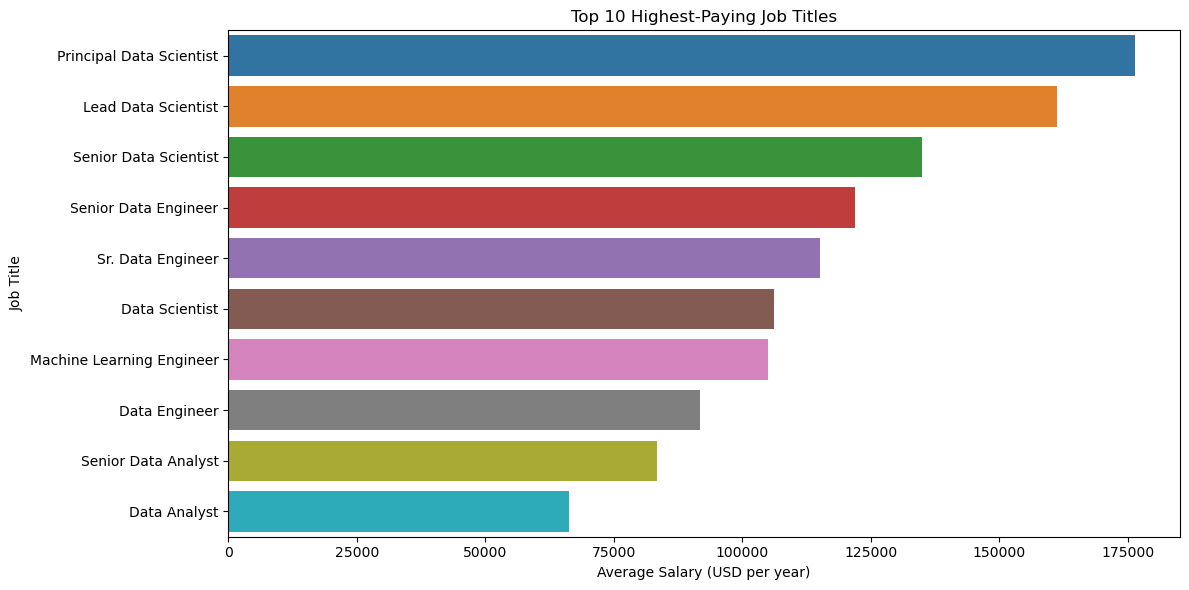

In [38]:
job_salary = (
    df.groupby("Job Title")
    .agg(
        Average_Salary=("Average_Salary", "mean"),
        Job_Count=("Average_Salary", "count")
    )
)

job_salary = job_salary[job_salary["Job_Count"] >= 5]

top_10_jobs = job_salary.nlargest(10, "Average_Salary")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_jobs.reset_index(),
    x="Average_Salary",
    y="Job Title"
)

plt.title("Top 10 Highest-Paying Job Titles")
plt.xlabel("Average Salary (USD per year)")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

In [39]:
df["Average_Salary"] = (
    df["Min_Salary"] + df["Max_Salary"]
) / 2

print(df[["Min_Salary", "Max_Salary", "Average_Salary"]].head(10))

   Min_Salary  Max_Salary  Average_Salary
0     53000.0     91000.0         72000.0
1     63000.0    112000.0         87500.0
2     80000.0     90000.0         85000.0
3     56000.0     97000.0         76500.0
4     86000.0    143000.0        114500.0
5     71000.0    119000.0         95000.0
6     54000.0     93000.0         73500.0
7     86000.0    142000.0        114000.0
8     38000.0     84000.0         61000.0
9    120000.0    160000.0        140000.0


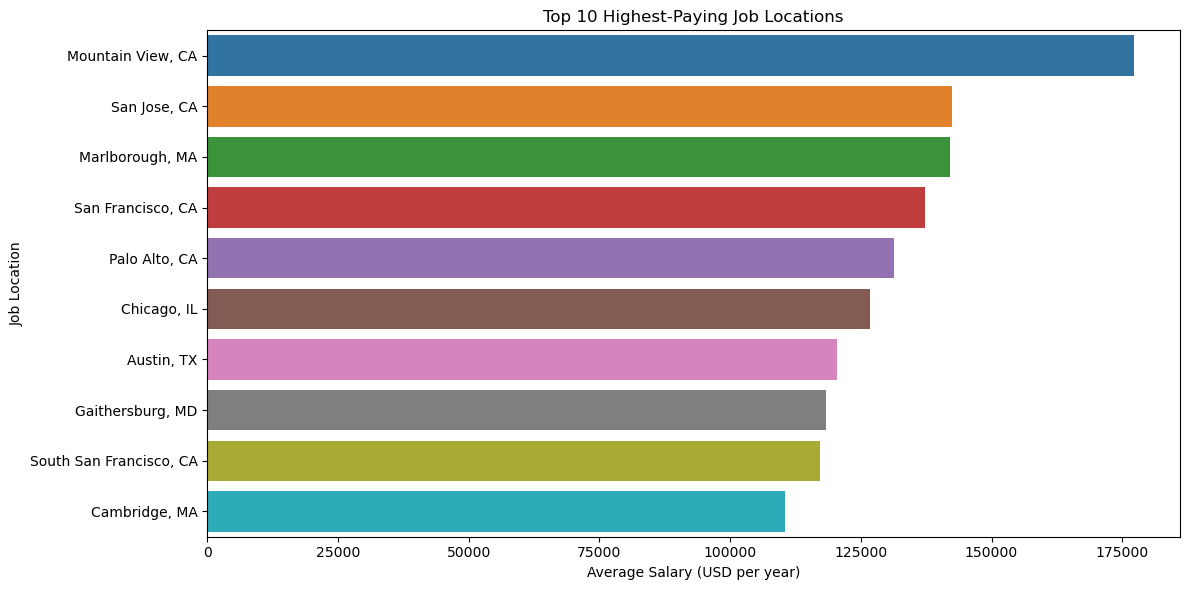

In [40]:
# Calculate average salary by location
location_salary = (
    df.groupby("Location")
    .agg(
        Average_Salary=("Average_Salary", "mean"),
        Job_Count=("Average_Salary", "count")
    )
    .reset_index()
)

# Keep locations with at least 5 job listings
location_salary = location_salary[
    location_salary["Job_Count"] >= 5
]

# Select top 10 locations by average salary
top_10_locations = location_salary.nlargest(
    10, "Average_Salary"
)

# Create visualization
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_locations,
    x="Average_Salary",
    y="Location"
)

plt.title("Top 10 Highest-Paying Job Locations")
plt.xlabel("Average Salary (USD per year)")
plt.ylabel("Job Location")
plt.tight_layout()
plt.show()

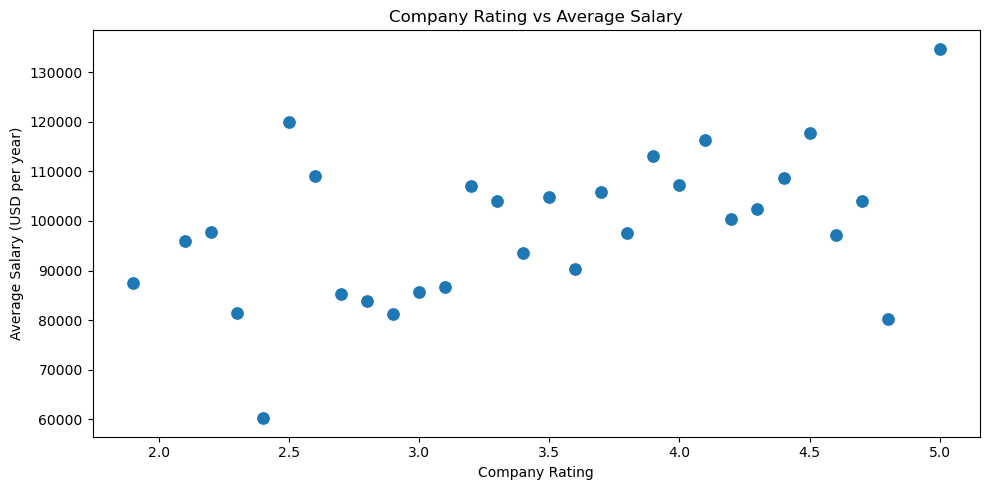

In [41]:
# Step 14: Company Rating vs Average Salary

rating_salary = df.groupby("Rating")["Average_Salary"].mean().reset_index()

rating_salary = rating_salary[rating_salary["Rating"] > 0]

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=rating_salary,
    x="Rating",
    y="Average_Salary",
    s=100
)

plt.title("Company Rating vs Average Salary")
plt.xlabel("Company Rating")
plt.ylabel("Average Salary (USD per year)")

plt.tight_layout()
plt.show()

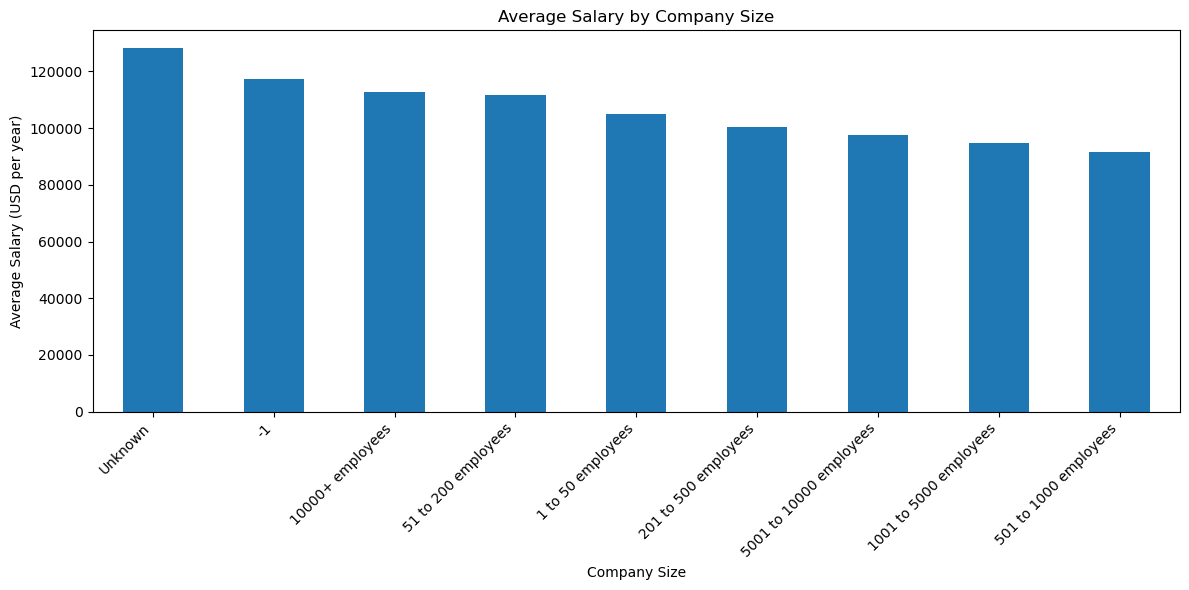

In [42]:
# Average salary by company size

size_salary = df.groupby("Size")["Average_Salary"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))
size_salary.plot(kind="bar")

plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD per year)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

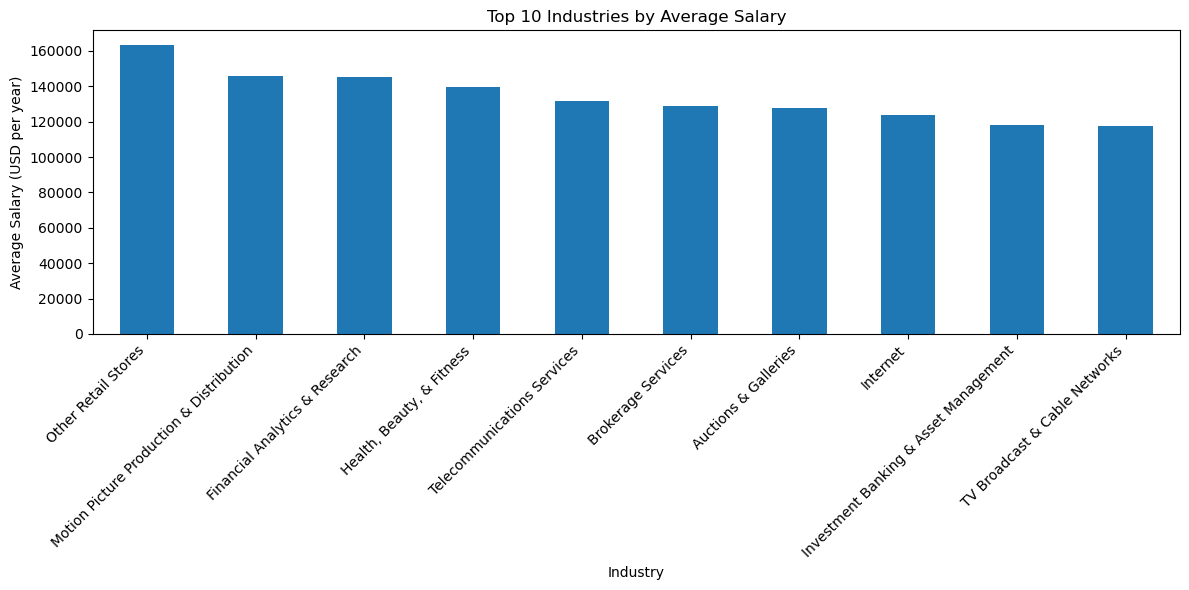

In [43]:
# Top 10 industries by average salary

industry_salary = (
    df.groupby("Industry")["Average_Salary"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
industry_salary.plot(kind="bar")

plt.title("Top 10 Industries by Average Salary")
plt.xlabel("Industry")
plt.ylabel("Average Salary (USD per year)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [44]:
# Check missing values

print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

Missing Values in Each Column:
Unnamed: 0             0
Job Title              0
Salary Estimate        0
Job Description        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Size                   0
Founded                0
Type of ownership      0
Industry               0
Sector                 0
Revenue                0
Competitors            0
Min_Salary           214
Max_Salary           214
Average_Salary       214
dtype: int64

Missing Value Percentage:
Average_Salary       22.384937
Max_Salary           22.384937
Min_Salary           22.384937
Job Title             0.000000
Competitors           0.000000
Revenue               0.000000
Sector                0.000000
Industry              0.000000
Type of ownership     0.000000
Unnamed: 0            0.000000
Size                  0.000000
Headquarters          0.000000
Location              0.000000
Company Name          0.000000
Rating                0.000000
Job Descriptio

In [45]:
# Inspect rows where salary values are missing

missing_salary = df[df["Min_Salary"].isnull()]

print("Number of rows with missing salary:", len(missing_salary))

print("\nSample missing salary records:")
print(
    missing_salary[
        ["Job Title", "Salary Estimate", "Company Name"]
    ].head(20).to_string(index=False)
)

Number of rows with missing salary: 214

Sample missing salary records:
                                           Job Title Salary Estimate                      Company Name
                                      Data Scientist              -1                         Mars\n3.9
                                      Data Scientist              -1                       Amount\n4.1
                                Data Science Analyst              -1                   Brightside\n5.0
                                       Data Engineer              -1                 Anson McCade\n4.5
                       Business Intelligence Analyst              -1                 Amica Mutual\n3.1
                                      Data Scientist              -1                     Blue Owl\n4.5
                                      Data Scientist              -1    Great-Circle Technologies\n2.2
                                      Data Scientist              -1                       Avlino\n4.9
 

In [46]:
# Create a separate dataset for salary prediction
df_model = df.dropna(subset=["Average_Salary"]).copy()

# Check the cleaned dataset
print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)

print("\nMissing values in Average_Salary:")
print(df_model["Average_Salary"].isnull().sum())


Original dataset shape: (956, 18)
Modeling dataset shape: (742, 18)

Missing values in Average_Salary:
0


In [47]:
# Check duplicate records
print("Duplicate rows:", df_model.duplicated().sum())

# Check dataset information
print("\nDataset shape:", df_model.shape)

# Check missing values in each column
print("\nMissing values:")
print(df_model.isnull().sum())

Duplicate rows: 0

Dataset shape: (742, 18)

Missing values:
Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Min_Salary           0
Max_Salary           0
Average_Salary       0
dtype: int64


In [48]:
# Select features for salary prediction
features = [
    "Job Title",
    "Rating",
    "Location",
    "Size",
    "Type of ownership",
    "Industry",
    "Sector",
    "Revenue"
]

# Input features (X)
X = df_model[features]

# Target variable (y)
y = df_model["Average_Salary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features:")
print(X.head())

print("\nTarget salary:")
print(y.head())

Features shape: (742, 8)
Target shape: (742,)

Input features:
                   Job Title  Rating         Location                    Size  \
0             Data Scientist     3.8  Albuquerque, NM   501 to 1000 employees   
1  Healthcare Data Scientist     3.4    Linthicum, MD        10000+ employees   
2             Data Scientist     4.8   Clearwater, FL   501 to 1000 employees   
3             Data Scientist     3.8     Richland, WA  1001 to 5000 employees   
4             Data Scientist     2.9     New York, NY     51 to 200 employees   

    Type of ownership                          Industry  \
0   Company - Private               Aerospace & Defense   
1  Other Organization  Health Care Services & Hospitals   
2   Company - Private                 Security Services   
3          Government                            Energy   
4   Company - Private           Advertising & Marketing   

                         Sector                           Revenue  
0           Aerospace & Def

In [49]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check the shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (593, 8)
Testing features: (149, 8)
Training target: (593,)
Testing target: (149,)


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

# Encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Create the model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [51]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"R² Percentage: {r2 * 100:.2f}%")

Model Evaluation Results
------------------------
MAE:  14403.05
RMSE: 22030.82
R² Score: 0.6904
R² Percentage: 69.04%


In [52]:
# Compare actual and predicted salaries
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison["Difference"] = (
    comparison["Actual Salary"] -
    comparison["Predicted Salary"]
).abs()

print("Actual vs Predicted Salary")
display(comparison.head(10).round(2))

Actual vs Predicted Salary


,Actual Salary,Predicted Salary,Difference
0,100500.0,124005.0,23505.0
1,48500.0,52780.0,4280.0
2,154500.0,148750.0,5750.0
3,122000.0,109140.0,12860.0
4,162000.0,139835.0,22165.0
5,107000.0,81135.0,25865.0
6,150500.0,159255.0,8755.0
7,44500.0,71464.6,26964.6
8,59500.0,72920.2,13420.2
9,51500.0,62790.0,11290.0


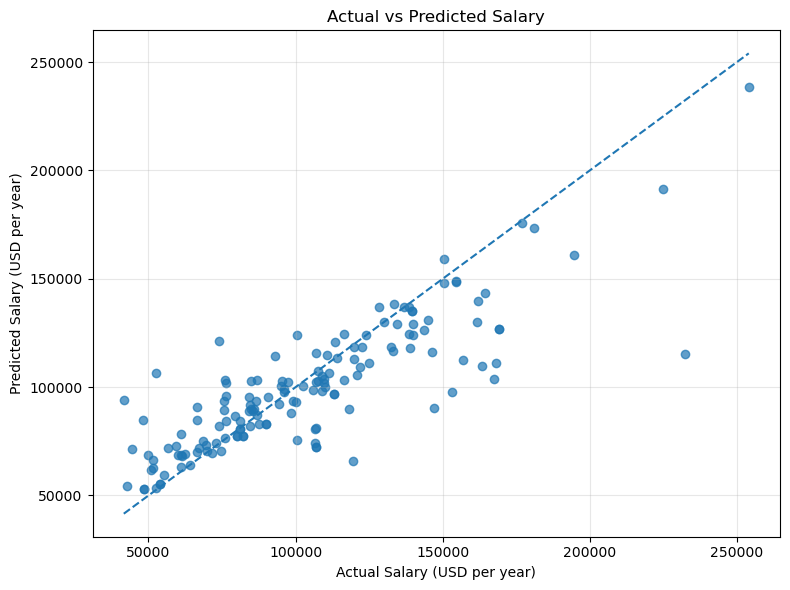

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction reference line
min_salary = min(y_test.min(), y_pred.min())
max_salary = max(y_test.max(), y_pred.max())

plt.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    linestyle="--"
)

plt.xlabel("Actual Salary (USD per year)")
plt.ylabel("Predicted Salary (USD per year)")
plt.title("Actual vs Predicted Salary")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from Random Forest
importances = model.named_steps["regressor"].feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Display top 15 important features
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

Top 15 Important Features:
                                                            Feature  Importance
                                                        num__Rating    0.077061
           cat__Job Title_Director II, Data Science - GRM Actuarial    0.059507
                                    cat__Location_Mountain View, CA    0.049116
                               cat__Job Title_Senior Data Scientist    0.047040
                                    cat__Location_San Francisco, CA    0.044237
                                 cat__Job Title_Lead Data Scientist    0.039561
                                         cat__Location_San Jose, CA    0.025437
                                      cat__Job Title_Data Scientist    0.024726
                            cat__Type of ownership_Company - Public    0.016218
                            cat__Job Title_Principal Data Scientist    0.015605
                      cat__Type of ownership_Nonprofit Organization    0.012494
             

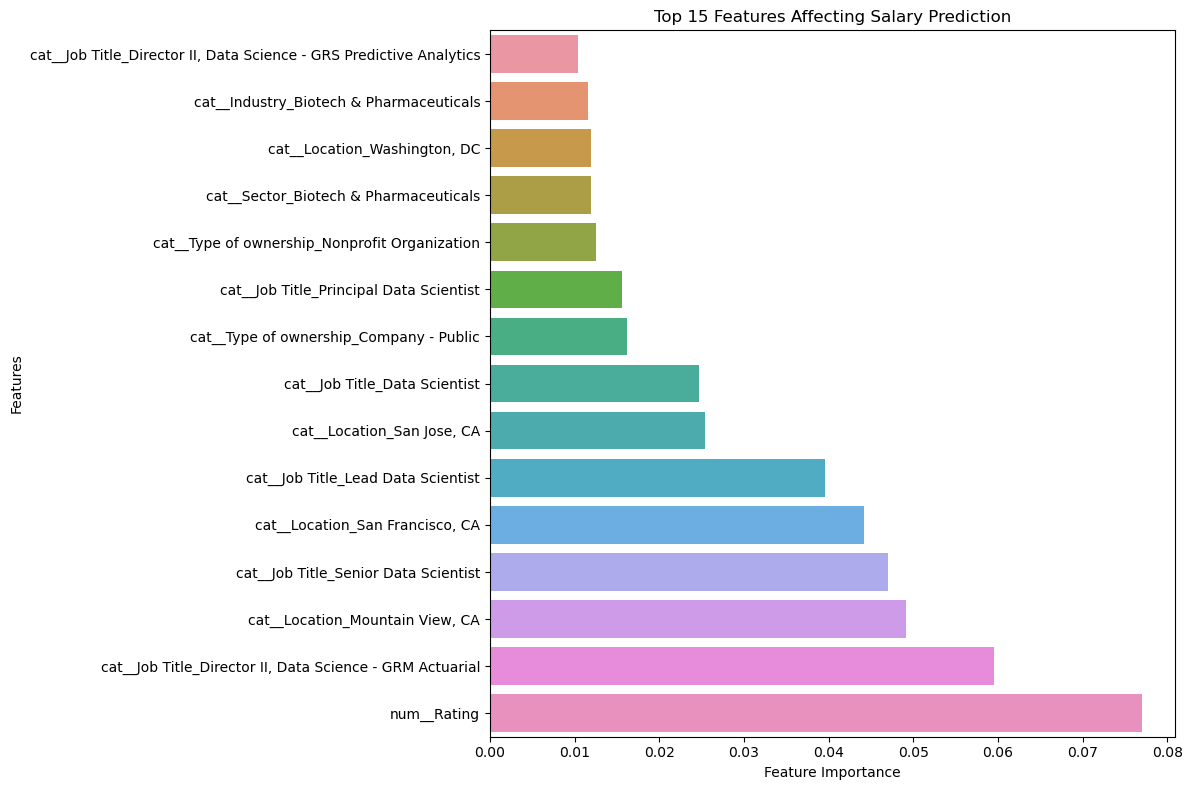

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 15 important features
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Affecting Salary Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()